In [1]:
!pip install rasterio matplotlib

   ---------------------------------------- 0.0/25.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/25.4 MB ? eta -:--:--
    --------------------------------------- 0.5/25.4 MB 1.3 MB/s eta 0:00:20
   - -------------------------------------- 0.8/25.4 MB 1.4 MB/s eta 0:00:18
   - -------------------------------------- 0.8/25.4 MB 1.4 MB/s eta 0:00:18
   - -------------------------------------- 1.0/25.4 MB 1.3 MB/s eta 0:00:20
   -- ------------------------------------- 1.3/25.4 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.3/25.4 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.6/25.4 MB 953.2 kB/s eta 0:00:26
   -- ------------------------------------- 1.6/25.4 MB 953.2 kB/s eta 0:00:26
   -- ------------------------------------- 1.8/25.4 MB 898.8 kB/s eta 0:00:27
   --- ------------------------------------ 2.1/25.4 MB 917.5 kB/s eta 0:00:26
   --- ------------------------------------ 2.4/25.4 MB 938.7 kB/s eta 0:00:25
   

In [3]:
!pip install rasterio tqdm

In [1]:
!pip install glob

ERROR: Could not find a version that satisfies the requirement glob (from versions: none)
ERROR: No matching distribution found for glob


# Displaying Input stack,lake mask and the bands in it

The 'input_stack.tiff' has 8 bands.


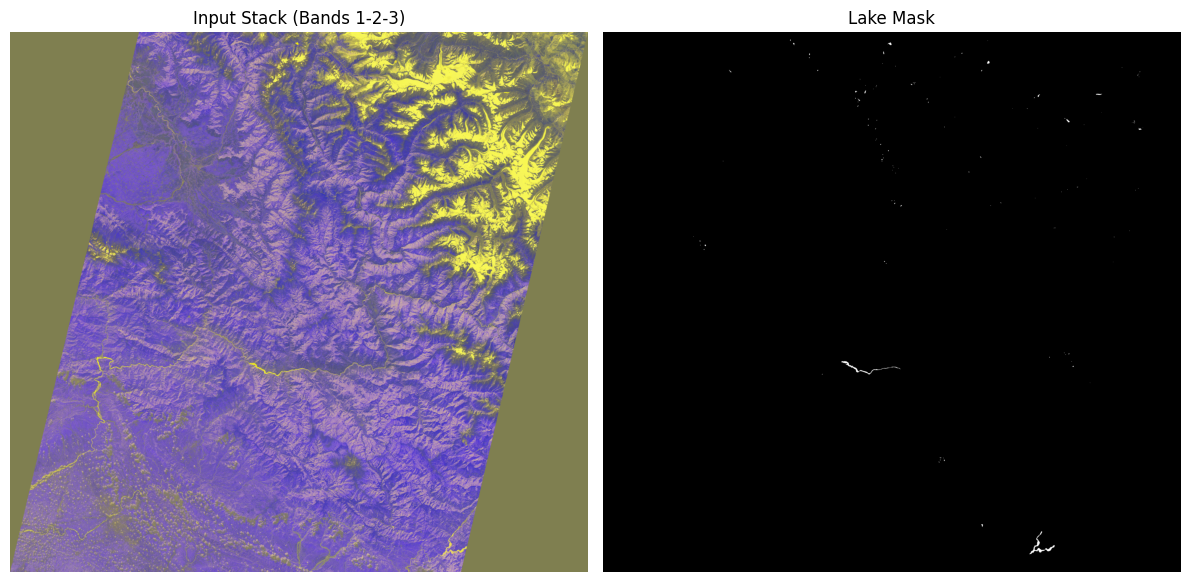

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# --- IMPORTANT: Replace with the actual paths to your files ---
input_stack_path = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\LISS3_1_input_stack.tif"
lake_mask_path = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\LISS3_1_lake_mask.tif"

try:
    # --- Process and display the multi-band input stack ---
    with rasterio.open(input_stack_path) as src:
        # Get the total number of bands and print it
        num_bands = src.count
        print(f"The 'input_stack.tiff' has {num_bands} bands.")

        # For display, we'll create an RGB image from the first three bands.
        # NOTE: LISS-3 Bands 2,3,4 are typically Green, Red, and Near-Infrared (NIR).
        # A common false-color composite is NIR-Red-Green (Bands 4-3-2).
        # We will read the first 3 bands you stacked for a basic visualization.
        # You can change the index numbers in [1, 2, 3] to visualize different bands.
        rgb_bands = src.read([1, 2, 3])

        # Normalize the bands to a 0-1 range for proper display
        def normalize(band):
            band_min, band_max = band.min(), band.max()
            return (band - band_min) / (band_max - band_min)

        # Apply normalization to each band and stack them
        normalized_rgb = np.dstack([normalize(rgb_bands[0]), normalize(rgb_bands[1]), normalize(rgb_bands[2])])


    # --- Process and display the single-band lake mask ---
    with rasterio.open(lake_mask_path) as src:
        lake_mask = src.read(1) # Read the first (and only) band


    # --- Plotting the images side-by-side ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Display the input stack
    ax1.imshow(normalized_rgb)
    ax1.set_title("Input Stack (Bands 1-2-3)")
    ax1.axis('off') # Hide axes ticks

    # Display the lake mask
    ax2.imshow(lake_mask, cmap='gray')
    ax2.set_title("Lake Mask")
    ax2.axis('off') # Hide axes ticks

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: Make sure the file paths are correct.")
except Exception as e:
    print(f"An error occurred: {e}")

###  This script will read your large input_stack and lake_mask files, cut them into 256x256 pixel chunks, and save themin the specified folders.

In [5]:
import os
import rasterio
from rasterio.windows import Window
from itertools import product
from tqdm import tqdm

def tile_raster(input_path, output_dir, output_prefix, patch_size=256):
    """
    Cuts a large raster into smaller tiles and saves them.

    Args:
        input_path (str): Path to the source raster file.
        output_dir (str): Directory to save the tiled chunks.
        output_prefix (str): Prefix for the output chunk filenames.
        patch_size (int): The width and height of the chunks in pixels.
    """
    chunk_id = 1
    
    # Open the source raster file
    with rasterio.open(input_path) as src:
        width = src.width
        height = src.height

        # Create a grid of offsets to iterate over the raster
        offsets = product(range(0, width, patch_size), range(0, height, patch_size))
        
        # Get the total number of chunks for the progress bar
        total_chunks = (width // patch_size + (1 if width % patch_size else 0)) * \
                       (height // patch_size + (1 if height % patch_size else 0))

        print(f"\nProcessing {os.path.basename(input_path)}...")
        
        # Iterate over the grid with a progress bar
        for col_off, row_off in tqdm(offsets, total=total_chunks):
            
            # Define the window for the current chunk
            window = Window(col_off=col_off, row_off=row_off, width=patch_size, height=patch_size)

            # Read the data from the source file for the given window
            # The 'boundless=True' flag handles cases where the window extends beyond the raster edges
            transform = src.window_transform(window)
            chunk_data = src.read(window=window, boundless=True, fill_value=src.nodata)
            
            # Get and update the metadata for the new chunk
            profile = src.profile
            profile.update({
                'height': chunk_data.shape[1],
                'width': chunk_data.shape[2],
                'transform': transform,
                'nodata': src.nodata
            })

            # Construct the full output path for the new chunk
            output_filepath = os.path.join(output_dir, f"{output_prefix}{chunk_id}.tif")

            # Write the chunk to a new file
            with rasterio.open(output_filepath, 'w', **profile) as dst:
                dst.write(chunk_data)
            
            chunk_id += 1
            
    return chunk_id - 1


if __name__ == '__main__':
    # --- Configuration: Define file paths and settings ---

    # Input file paths
    input_stack_path = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\LISS3_1_input_stack.tif"
    lake_mask_path = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\LISS3_1_lake_mask.tif"

    # Output directories
    input_stack_output_dir = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\chunks"
    lake_mask_output_dir = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\chunks"

    # Create output directories if they don't exist
    os.makedirs(input_stack_output_dir, exist_ok=True)
    os.makedirs(lake_mask_output_dir, exist_ok=True)

    # --- Start Processing ---
    print("Starting the tiling process...")

    # Tile the input stack
    num_input_chunks = tile_raster(
        input_path=input_stack_path,
        output_dir=input_stack_output_dir,
        output_prefix="input_stack_chunk_"
    )
    print(f"Finished creating {num_input_chunks} input stack chunks.")

    # Tile the lake mask
    num_mask_chunks = tile_raster(
        input_path=lake_mask_path,
        output_dir=lake_mask_output_dir,
        output_prefix="lake_mask_chunk_"
    )
    print(f"Finished creating {num_mask_chunks} lake mask chunks.")

    print("\nStep 1: Tiling complete!")

Starting the tiling process...

Processing LISS3_1_input_stack.tif...


100%|████████████████████████████████████████████████████████████████████████████████| 899/899 [01:15<00:00, 11.91it/s]


Finished creating 899 input stack chunks.

Processing LISS3_1_lake_mask.tif...


100%|███████████████████████████████████████████████████████████████████████████████| 899/899 [00:08<00:00, 108.38it/s]

Finished creating 899 lake mask chunks.

Step 1: Tiling complete!


### Scaning all the chunks, classifying them into positive(with lakes) and negative(no lakes) and then copy a 1:2 ratio of positive-to-negative chunks into new "filtered_chunks" directories.

In [3]:
import os
import glob
import shutil
import random
import rasterio
import numpy as np
from tqdm import tqdm

def filter_and_copy_chunks(mask_chunks_dir, image_chunks_dir,
                           filtered_mask_dir, filtered_image_dir,
                           ratio_neg_to_pos=2):
    """
    Filters chunks based on the presence of features in the mask and copies
    them to new directories based on a specified ratio.
    """
    # --- 1. Identify Positive and Negative Samples ---
    print("Scanning mask chunks to identify positive and negative samples...")
    
    positive_samples = []
    negative_samples = []

    # Get a list of all mask files
    mask_files = glob.glob(os.path.join(mask_chunks_dir, "*.tif"))

    for mask_path in tqdm(mask_files, desc="Scanning masks"):
        with rasterio.open(mask_path) as src:
            mask_data = src.read(1)
            # If any pixel is greater than 0, it's a positive sample
            if np.any(mask_data > 0):
                positive_samples.append(mask_path)
            else:
                negative_samples.append(mask_path)

    num_pos = len(positive_samples)
    num_neg = len(negative_samples)
    print(f"\nFound {num_pos} positive chunks (with lakes).")
    print(f"Found {num_neg} negative chunks (without lakes).")


    # --- 2. Select Files to Copy Based on Ratio ---
    num_neg_to_select = min(num_neg, num_pos * ratio_neg_to_pos)
    
    print(f"\nSelecting all {num_pos} positive chunks.")
    print(f"Randomly selecting {num_neg_to_select} negative chunks for a ~1:{ratio_neg_to_pos} ratio.")

    # Randomly select the negative samples
    selected_negatives = random.sample(negative_samples, num_neg_to_select)
    
    # Combine the lists of files to be copied
    files_to_copy = positive_samples + selected_negatives
    random.shuffle(files_to_copy) # Shuffle to mix them up


    # --- 3. Copy Selected Files to Filtered Directories ---
    print(f"\nCopying {len(files_to_copy)} total chunks to filtered directories...")

    for mask_source_path in tqdm(files_to_copy, desc="Copying files"):
        mask_filename = os.path.basename(mask_source_path)
        
        # Determine the corresponding image chunk filename
        image_filename = mask_filename.replace('lake_mask_chunk_', 'input_stack_chunk_')
        image_source_path = os.path.join(image_chunks_dir, image_filename)

        # Define destination paths
        mask_dest_path = os.path.join(filtered_mask_dir, mask_filename)
        image_dest_path = os.path.join(filtered_image_dir, image_filename)

        # Copy the files
        shutil.copy2(mask_source_path, mask_dest_path)
        shutil.copy2(image_source_path, image_dest_path)
        
    print("\n--- Filtering Summary ---")
    print(f"Positive chunks copied: {num_pos}")
    print(f"Negative chunks copied: {num_neg_to_select}")
    print(f"Total chunks in filtered directories: {len(files_to_copy)}")


if __name__ == '__main__':
    # --- Configuration ---
    # Input directories containing all chunks
    IMG_CHUNKS_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\chunks"
    MSK_CHUNKS_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\chunks"

    # Output directories for the filtered chunks
    FILTERED_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\filtered_chunks"
    FILTERED_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\filtered_chunks"

    # Create output directories if they don't exist
    os.makedirs(FILTERED_IMG_DIR, exist_ok=True)
    os.makedirs(FILTERED_MSK_DIR, exist_ok=True)
    
    # --- Run the Process ---
    filter_and_copy_chunks(
        mask_chunks_dir=MSK_CHUNKS_DIR,
        image_chunks_dir=IMG_CHUNKS_DIR,
        filtered_mask_dir=FILTERED_MSK_DIR,
        filtered_image_dir=FILTERED_IMG_DIR,
        ratio_neg_to_pos=1
    )

    print("\nStep 2: Filtering and copying complete!")

Scanning mask chunks to identify positive and negative samples...


Scanning masks: 100%|███████████████████████████████████████████████████████████████| 899/899 [00:04<00:00, 182.78it/s]



Found 86 positive chunks (with lakes).
Found 813 negative chunks (without lakes).

Selecting all 86 positive chunks.
Randomly selecting 86 negative chunks for a ~1:1 ratio.

Copying 172 total chunks to filtered directories...


Copying files: 100%|████████████████████████████████████████████████████████████████| 172/172 [00:00<00:00, 225.31it/s]


--- Filtering Summary ---
Positive chunks copied: 86
Negative chunks copied: 86
Total chunks in filtered directories: 172

Step 2: Filtering and copying complete!


### fILTERING AND SAVING THE CHUNKS WHICH ARE ONLY POSITIVE

In [1]:
import os
import glob
import shutil
import random
import rasterio
import numpy as np
from tqdm import tqdm

def filter_and_copy_positive_chunks(mask_chunks_dir, image_chunks_dir,
                                    filtered_mask_dir, filtered_image_dir):
    """
    Filters chunks that have at least one lake pixel (mask > 0)
    and copies the corresponding image and mask files to new directories.
    """
    print("Scanning mask chunks to identify positive samples...")

    positive_samples = []

    # Get all mask files
    mask_files = glob.glob(os.path.join(mask_chunks_dir, "*.tif"))

    for mask_path in tqdm(mask_files, desc="Scanning masks"):
        with rasterio.open(mask_path) as src:
            mask_data = src.read(1)
            if np.any(mask_data > 0):
                positive_samples.append(mask_path)

    num_pos = len(positive_samples)
    print(f"\nFound {num_pos} positive chunks (with lakes).")

    # Shuffle for randomness
    random.shuffle(positive_samples)

    print(f"\nCopying {num_pos} positive chunks to filtered directories...")

    for mask_source_path in tqdm(positive_samples, desc="Copying files"):
        mask_filename = os.path.basename(mask_source_path)
        image_filename = mask_filename.replace('lake_mask_chunk_', 'input_stack_chunk_')
        image_source_path = os.path.join(image_chunks_dir, image_filename)

        # Ensure image exists
        if not os.path.exists(image_source_path):
            print(f"Warning: Missing image for {mask_filename}, skipping.")
            continue

        mask_dest_path = os.path.join(filtered_mask_dir, mask_filename)
        image_dest_path = os.path.join(filtered_image_dir, image_filename)

        shutil.copy2(mask_source_path, mask_dest_path)
        shutil.copy2(image_source_path, image_dest_path)

    print("\n--- Filtering Summary ---")
    print(f"Positive chunks copied: {num_pos}")
    print(f"Total chunks in filtered directories: {num_pos}")


if __name__ == '__main__':
    # Input directories
    IMG_CHUNKS_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\chunks"
    MSK_CHUNKS_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\chunks"

    # Output directories for filtered positive chunks
    FILTERED_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\filtered_chunks"
    FILTERED_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\filtered_chunks"

    # Create output dirs if not exist
    os.makedirs(FILTERED_IMG_DIR, exist_ok=True)
    os.makedirs(FILTERED_MSK_DIR, exist_ok=True)

    # Run the filtering
    filter_and_copy_positive_chunks(
        mask_chunks_dir=MSK_CHUNKS_DIR,
        image_chunks_dir=IMG_CHUNKS_DIR,
        filtered_mask_dir=FILTERED_MSK_DIR,
        filtered_image_dir=FILTERED_IMG_DIR
    )

    print("\nStep 2: Positive filtering and copying complete!")


Scanning mask chunks to identify positive samples...


Scanning masks: 100%|███████████████████████████████████████████████████████████████| 899/899 [00:05<00:00, 173.80it/s]



Found 86 positive chunks (with lakes).

Copying 86 positive chunks to filtered directories...


Copying files: 100%|██████████████████████████████████████████████████████████████████| 86/86 [00:00<00:00, 272.80it/s]


--- Filtering Summary ---
Positive chunks copied: 86
Total chunks in filtered directories: 86

Step 2: Positive filtering and copying complete!


### Splitting the data in 80:10:10 ratio for training , testing and validation

In [4]:
import os
import glob
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

def split_and_copy_to_specific_dirs(image_dir, mask_dir, output_paths):
    """
    Splits files into train/val/test sets and copies them into a
    specific, predefined directory structure.
    """
    # --- 1. Create All Necessary Output Directories ---
    print("Creating destination directories...")
    for path in output_paths.values():
        os.makedirs(path, exist_ok=True)
    print("Directories created successfully.")

    # --- 2. Get and Split the List of Files ---
    print("\nFinding all filtered image chunks...")
    all_image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))

    if not all_image_files:
        print(f"Error: No image files found in {image_dir}")
        return

    print(f"Found {len(all_image_files)} total filtered chunks.")

    # Split into 80% train, 10% validation, 10% test
    train_val_files, test_files = train_test_split(
        all_image_files, test_size=0.10, random_state=42
    )
    train_files, val_files = train_test_split(
        train_val_files, test_size=(0.10 / 0.90), random_state=42
    )

    file_splits = {
        "Training": train_files,
        "Validation": val_files,
        "Testing": test_files
    }
    print("\nDataset split determined:")
    for name, files in file_splits.items():
        print(f"  - {name} samples: {len(files)}")

    # --- 3. Define the Copying Function ---
    def copy_file_set(files, img_dest_dir, mask_dest_dir):
        """Copies a list of image files and their corresponding masks to specified folders."""
        for img_source_path in tqdm(files, desc=f"Copying to {os.path.basename(img_dest_dir)}"):
            img_filename = os.path.basename(img_source_path)
            mask_filename = img_filename.replace('input_stack_chunk_', 'lake_mask_chunk_')
            mask_source_path = os.path.join(mask_dir, mask_filename)

            img_dest_path = os.path.join(img_dest_dir, img_filename)
            mask_dest_path = os.path.join(mask_dest_dir, mask_filename)

            shutil.copy2(img_source_path, img_dest_path)
            shutil.copy2(mask_source_path, mask_dest_path)

    # --- 4. Execute the Copying Process for Each Set ---
    print("\nStarting file copy process...")
    copy_file_set(train_files, output_paths['train_img'], output_paths['train_mask'])
    copy_file_set(val_files, output_paths['val_img'], output_paths['val_mask'])
    copy_file_set(test_files, output_paths['test_img'], output_paths['test_mask'])


if __name__ == '__main__':
    # --- Configuration ---
    # Input directories with the filtered chunks
    FILTERED_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\filtered_chunks"
    FILTERED_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\filtered_chunks"

    # Define the specific output directories as you requested
    # Note: Corrected a typo from 'linput_stack' to 'input_stack' for consistency
    output_directory_paths = {
        'train_mask': r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\training",
        'val_mask':   r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\validation",
        'test_mask':  r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\testing",
        'train_img':  r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\training",
        'val_img':    r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\validation",
        'test_img':   r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\testing"
    }

    # --- Run the Process ---
    split_and_copy_to_specific_dirs(
        image_dir=FILTERED_IMG_DIR,
        mask_dir=FILTERED_MSK_DIR,
        output_paths=output_directory_paths
    )

    print("\nStep 3: Splitting and copying to your specified directories is complete!")

Creating destination directories...
Directories created successfully.

Finding all filtered image chunks...
Found 172 total filtered chunks.

Dataset split determined:
  - Training samples: 136
  - Validation samples: 18
  - Testing samples: 18

Starting file copy process...


Copying to testing: 100%|█████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 333.94it/s]


Step 3: Splitting and copying to your specified directories is complete!
